# Kaggle playground series: 5-11 (2025) competition

The following illustrates some steps to segment and model loan applicant data, using data from the Kaggle playground series (__https://www.kaggle.com/competitions/playground-series-s5e11/overview__)


Question to be addresssed by the data analysis: **Predict loan payment, with a model assessed by AUC**


## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [2]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline, FeatureUnion, make_pipeline
from sklearn.cluster import KMeans, FeatureAgglomeration
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, davies_bouldin_score, calinski_harabasz_score

from xgboost import XGBClassifier

## Load and explore train data

In [3]:
train_data = pd.read_csv('k_5_11_train.csv')
train_data.shape

(593994, 13)

The consists of 13 columns, where the first is a redundant `id` column and the last is the label to be predicted, `loan_paid_back`. Six of the columns contain categorical data. There are no `null` or missing values.

In [4]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  str    
 7   marital_status        593994 non-null  str    
 8   education_level       593994 non-null  str    
 9   employment_status     593994 non-null  str    
 10  loan_purpose          593994 non-null  str    
 11  grade_subgrade        593994 non-null  str    
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory usage: 84.0 MB


In [5]:
train_data.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [6]:
train_data.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


The numerical features have large value ranges, and these will be scaled to balance their weights on the model.

Of the categorical features in the data, some have few (e.g. `gender`) unique entries while others have many more (e.g. `grade_subgrade`). Most of the categorical columns can be one-hot encoded. The `education_level` and `grade_subgrade` columns lend themselves to ordinal encoding.

In [7]:
train_data.select_dtypes(exclude='number').nunique()

gender                3
marital_status        4
education_level       5
employment_status     5
loan_purpose          8
grade_subgrade       30
dtype: int64

The dataset is not balanced, although the imbalance is not extreme:

In [8]:
print(f'Average percentage of loans paid back: {train_data.loan_paid_back.mean():.2%}')

Average percentage of loans paid back: 79.88%


## Visualize relationships between features and label

The first set of visuals are for the numerical features. Their distributions across the two class labels are shown in the boxplots below.

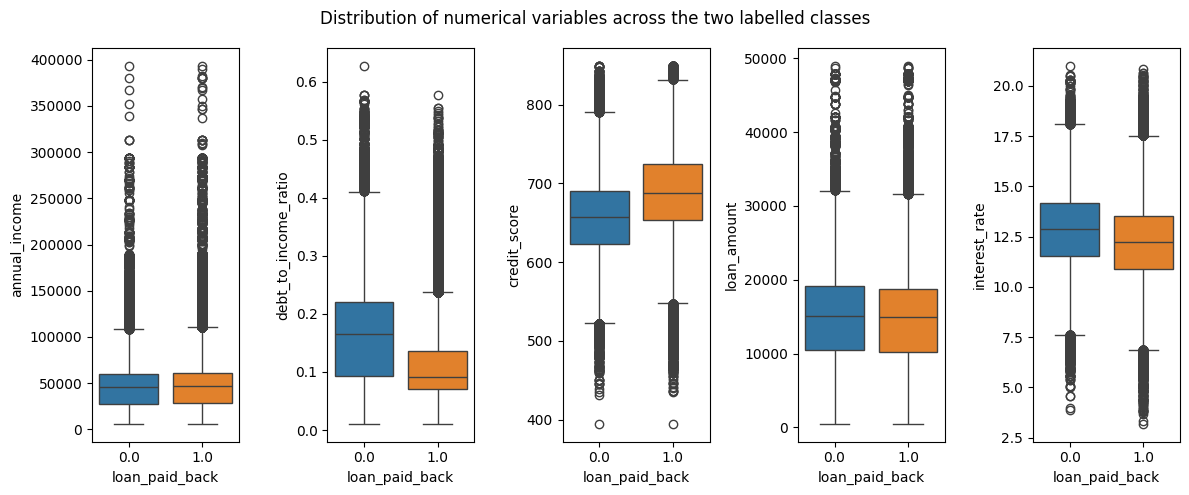

In [9]:
num_vars = train_data.select_dtypes(include='number').columns.to_list()
num_vars.remove('id')
num_vars.remove('loan_paid_back')

fig, ax = plt.subplots(1,len(num_vars), figsize=(12,5))

for i, col in enumerate(num_vars):
    sns.boxplot(train_data, y=col, x='loan_paid_back', hue='loan_paid_back', legend=False, ax=ax[i])

plt.suptitle('Distribution of numerical variables across the two labelled classes')
plt.tight_layout()
plt.show()

On average, individuals that are more likely to pay back their loans are those with lower `debt_to_income_ratio`, higher `credit_score` and lower `interest_rate`. All five numerical features have outliers though, which should be dealt with if e.g. a logistic regression model is chosen. The number of rows with outliers for each feature are as below.

In [10]:
num_outliers = []

for i, col in enumerate(num_vars):
    q1, q3 = train_data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    num_outliers.append(train_data[(train_data[col] > (q3 + iqr*1.5)) | (train_data[col] < (q1 - iqr*1.5))].shape[0])

for i, col in enumerate(num_vars):
    print(f'{col}: \t{num_outliers[i]:15,} outliers')

annual_income: 	         15,917 outliers
debt_to_income_ratio: 	         17,556 outliers
credit_score: 	          5,901 outliers
loan_amount: 	          2,902 outliers
interest_rate: 	          5,136 outliers


Next, bar graphs showing the average fraction loan_paid_back for each categorical value are given.

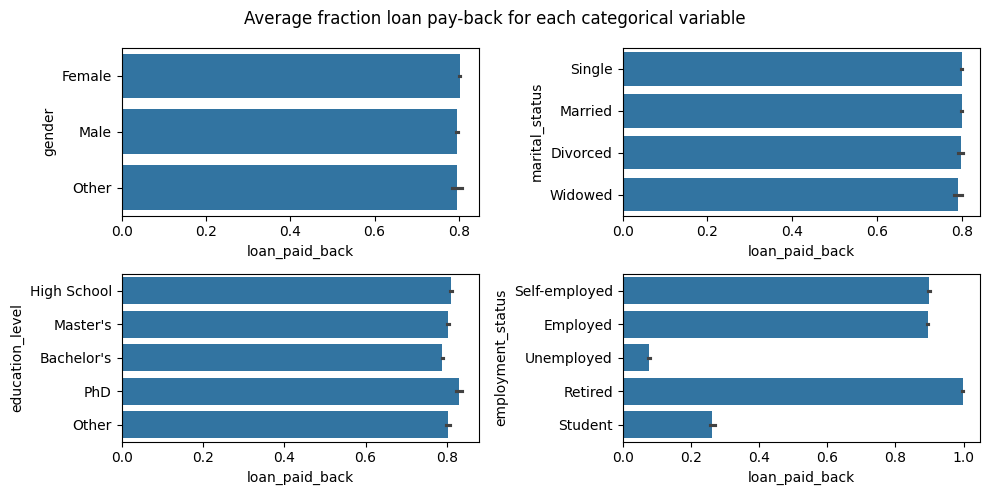

In [11]:
cat_vars_few = [col for col in train_data.select_dtypes(exclude='number').columns if train_data[col].nunique()<=5]

fig, ax = plt.subplots(2,2, figsize=(10,5))

for i, col in enumerate(cat_vars_few):
    sns.barplot(train_data, y=col, x='loan_paid_back', ax=ax.flat[i])

plt.suptitle('Average fraction loan pay-back for each categorical variable')
plt.tight_layout()
plt.show()

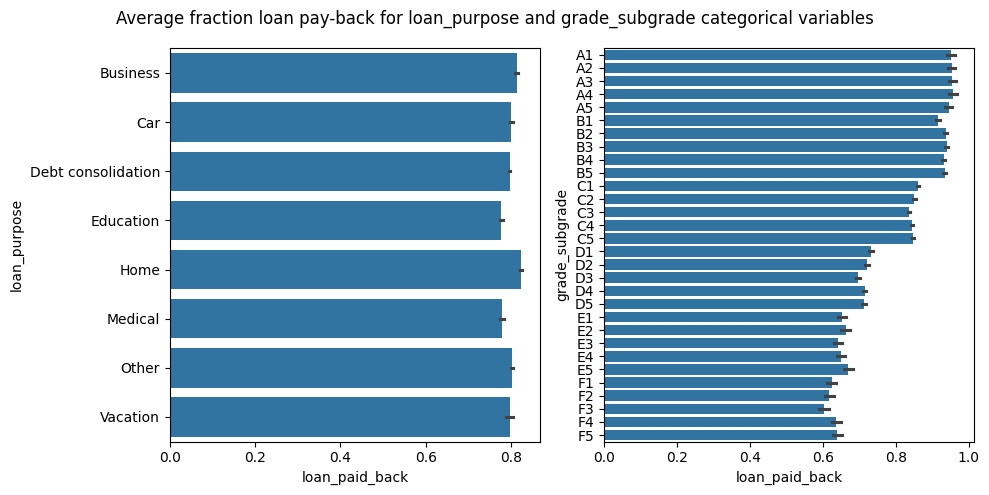

In [12]:
cat_vars_many = [col for col in train_data.select_dtypes(exclude='number').columns if train_data[col].nunique()>5]

fig, ax = plt.subplots(1,2, figsize=(10,5))

for i, col in enumerate(cat_vars_many):
    sns.barplot(train_data, y=col, x='loan_paid_back', order=sorted(train_data[col].unique()), ax=ax[i])

plt.suptitle('Average fraction loan pay-back for loan_purpose and grade_subgrade categorical variables')
plt.tight_layout()
plt.show()

On average, `Unemployed` and `Students` in the `employment_status` feature as well as those with lower `grade_subgrade` tend to pay back their loans less frequently.

In summary, the following features seem to be of importance:
- `debt_to_income_ratio`
- `credit_score`
- `interest_rate`
- `employment_status`
- `grade_subgrade`

Since some of the features are likely to be correlated (e.g. `employment_status` and `debt_to_income_ratio`, `credit_score` and `interest_rate`, etc.), feature selection & engineering will be used to possibly reduce the number of important features.

## Feature selection & engineering

A subset of the data is set aside for validation purposes (`X_val`, `y_val`) while the rest will be used in further exploratory analyses as well as model construction.

In [13]:
X = train_data.copy()
y = X.pop('loan_paid_back')
X.shape

(593994, 12)

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, stratify=y, random_state=0)
X_train.shape

(475195, 12)

The categorical features `education_level` and `grade_subgrade` lend themselves to ordinal encoding, while the rest of the categorical features can be one-hot encoded. Numerical features are scaled and then all are combined into dataframe `df` that will be used for exploratory modelling and analyses.

In [15]:
ed_lvl = X_train.education_level
ed_lvl.unique()

<ArrowStringArray>
['Master's', 'High School', 'Bachelor's', 'Other', 'PhD']
Length: 5, dtype: str

In [16]:
ed_order = [["Other", "High School", "Bachelor's", "Master's", "PhD"]]

enc_ed = OrdinalEncoder(categories=ed_order)
enc_ed.fit(ed_lvl.to_frame())
ed_lvl_col = enc_ed.transform(ed_lvl.to_frame())
ed_sc = QuantileTransformer(output_distribution='normal', random_state=0).fit_transform(ed_lvl_col)

grade = X_train.grade_subgrade
grade_order = [sorted(grade.unique())]

enc_gr = OrdinalEncoder(categories=grade_order)
enc_gr.fit(grade.to_frame())
grade_col = enc_gr.transform(grade.to_frame())
grade_sc = QuantileTransformer(output_distribution='normal', random_state=0).fit_transform(grade_col)

cat_vars = X_train.select_dtypes(exclude='number').columns.to_list()
cat_vars.remove('grade_subgrade')
cat_vars.remove('education_level')
cat_cols = pd.get_dummies(X_train[cat_vars])

num_vars = X_train.select_dtypes(include='number').columns.to_list()
num_vars.remove('id')
num_cols = QuantileTransformer(output_distribution='normal', random_state=0).fit_transform(X_train[num_vars])

df = pd.concat([pd.DataFrame(num_cols, columns=num_vars, index=X_train.index), 
                cat_cols, 
                pd.DataFrame(ed_sc, columns=['education_level'], index=X_train.index), 
                pd.DataFrame(grade_sc, columns=['grade_subgrade'], index=X_train.index)], 
               axis=1)

df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,...,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,education_level,grade_subgrade
320849,-0.014482,-0.095492,1.181921,0.369811,-1.428482,False,True,False,False,False,...,False,False,True,False,False,False,False,False,1.312981,-1.942703
122652,-1.420248,1.068522,0.274391,0.122539,2.332273,False,True,False,False,False,...,False,False,False,False,False,True,False,False,-0.837338,-0.630254
2894,-0.267884,0.151121,0.611996,0.140211,0.184203,True,False,False,False,True,...,False,False,False,False,True,False,False,False,1.312981,-0.630254
96596,-0.710666,1.365257,-1.705570,-1.384577,0.567211,True,False,False,False,True,...,False,False,True,False,False,False,False,False,0.234219,1.710968
224434,-0.201478,-1.220640,0.080379,-0.735756,-0.548158,False,True,False,False,True,...,False,False,True,False,False,False,False,False,0.234219,0.133379


The above transformations are confirmed by listing the unique dtypes in the dataframe:

In [17]:
df.dtypes.unique()

array([dtype('float64'), dtype('bool')], dtype=object)

The mutual information score indicates the features that have the most influence on the labelled class:

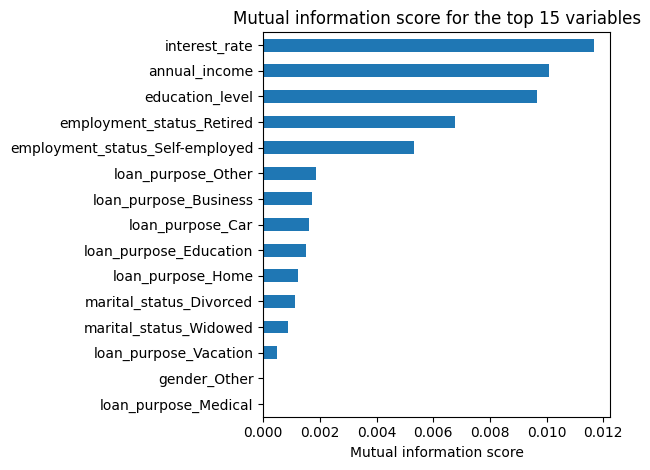

In [18]:
mi_scores = mutual_info_classif(df, y_train)

pd.Series(mi_scores, index=df.columns.to_list()).sort_values(ascending=True).head(15).plot(kind='barh')
plt.title('Mutual information score for the top 15 variables')
plt.xlabel('Mutual information score')
plt.tight_layout()
plt.show()

Principal component analysis along with feature agglomeration is used to try to reduce the number and dimensionality of the features:

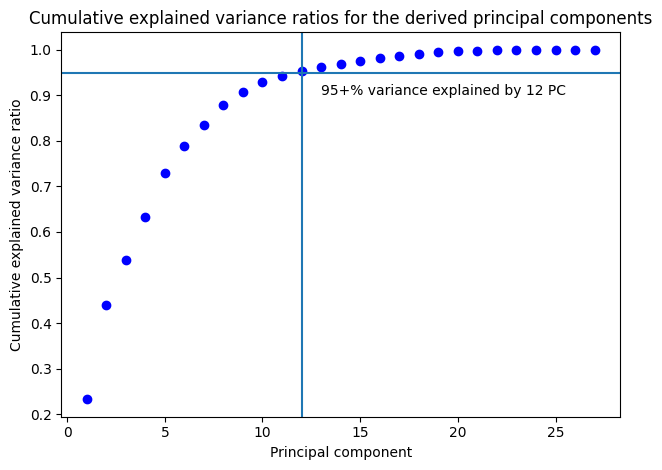

In [19]:
pca_eda = PCA()
pca_eda.fit(df)

num_pc = sum(np.cumsum(pca_eda.explained_variance_ratio_)<0.95)+1

plt.plot(range(1,len(pca_eda.explained_variance_ratio_)+1), np.cumsum(pca_eda.explained_variance_ratio_), 'bo')
plt.axhline(0.95)
plt.axvline(num_pc)
plt.annotate(f'95+% variance explained by {num_pc} PC', (num_pc+1,0.9))
plt.title('Cumulative explained variance ratios for the derived principal components')
plt.xlabel('Principal component')
plt.ylabel('Cumulative explained variance ratio')
plt.tight_layout()
plt.show()

In [20]:
num_pc = []
num_clust = range(2, df.shape[1])

for i in num_clust:
    agg = FeatureAgglomeration(n_clusters=i)
    agg.fit(df)
    df_red = agg.transform(df)
    pca_red = PCA()
    pca_red.fit(df_red)
    num_pc.append(sum(np.cumsum(pca_red.explained_variance_ratio_)<=0.95)+1)

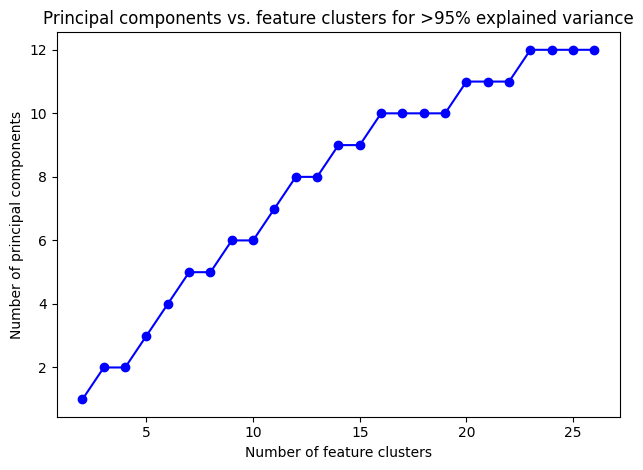

In [21]:
plt.plot(num_clust, num_pc, 'bo-')
plt.title('Principal components vs. feature clusters for >95% explained variance')
plt.xlabel('Number of feature clusters')
plt.ylabel('Number of principal components')
plt.tight_layout()
plt.show()

27 features can be grouped into 23 feature clusters, and then further reduced to 12 orthogonal principal components. However, the clustering does not significantly reduce the number of features (27 to 23) and will not be included in the model. Using all features and 12 principal components, the data is grouped into 8 clusters as identied by the metrics in the plots below:

In [22]:
pca_cl = PCA(n_components=12)
pca_cl.fit(df)
df_pca = pca_cl.transform(df)

In [23]:
# Try clustering the customers with non-pca data

inertia = []
dv = []
ch = []
num_range = range(2,20)

for i in num_range:
    kmeans = KMeans(n_clusters=i, random_state=10)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)
    dv.append(davies_bouldin_score(df, kmeans.predict(df_pca)))
    ch.append(calinski_harabasz_score(df, kmeans.predict(df_pca)))

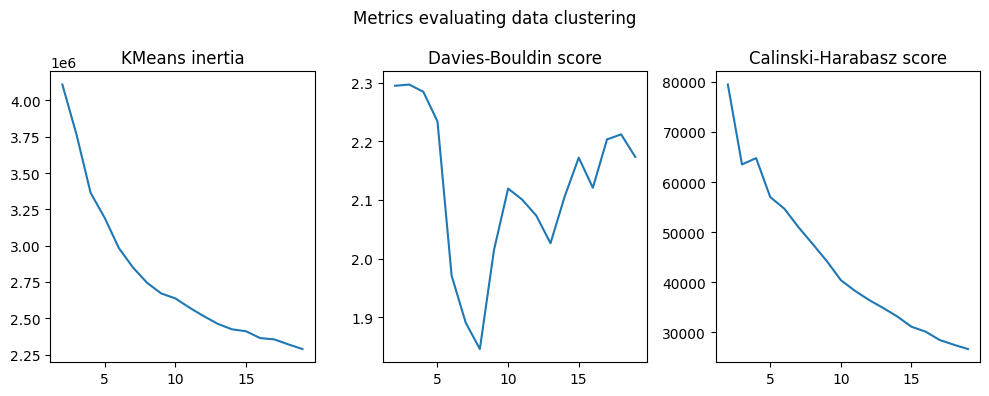

In [24]:
fig, ax = plt.subplots(1,3,figsize=(10,4))

ax[0].plot(num_range, inertia, '-')
ax[0].set(title='KMeans inertia')
ax[1].plot(num_range, dv, '-')
ax[1].set(title='Davies-Bouldin score')
ax[2].plot(num_range, ch, '-')
ax[2].set(title='Calinski-Harabasz score')

plt.suptitle('Metrics evaluating data clustering')
plt.tight_layout()
plt.show()

The data is segmented according to the 8 clusters, and then visualized to see common attributes amongst the clusters. There are noticeable differences in the `Average loan_paid_back` in each cluster.

In [25]:
kmeans8 = KMeans(n_clusters=8, random_state=10)
kmeans8.fit(df_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",10
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [26]:
pd.concat([pd.DataFrame(kmeans8.predict(df_pca), index=y_train.index, columns=['Cluster']), y_train], axis=1).groupby('Cluster').agg(Avg_loan_paid_back=('loan_paid_back', 'mean'), Num_rows=('loan_paid_back', 'count'))

,Avg_loan_paid_back,Num_rows
Cluster,,
0,0.660880,76961
1,0.830148,8790
2,0.800533,21372
3,0.678014,72115
4,0.763993,74642
5,0.933890,70171
6,0.910022,76341
7,0.847586,74803


In [27]:
df_cls = pd.concat([X_train.copy(), 
                    pd.DataFrame(kmeans8.predict(df_pca), index=y_train.index, columns=['Cluster']), 
                    y_train], axis=1)
df_cls.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,Cluster,loan_paid_back
320849,320849,46690.39,0.093,743,17145.12,9.58,Male,Single,Master's,Employed,Debt consolidation,B1,5,1.0
122652,122652,17223.16,0.195,695,15786.86,17.15,Male,Single,High School,Student,Medical,C2,3,0.0
2894,2894,39079.56,0.101,715,15908.88,12.73,Female,Married,Master's,Employed,Home,C2,3,1.0
96596,96596,27556.54,0.227,576,5481.90,13.45,Female,Married,Bachelor's,Unemployed,Debt consolidation,F1,0,0.0
224434,224434,40668.09,0.058,686,10170.13,11.23,Male,Married,Bachelor's,Employed,Debt consolidation,C5,6,1.0


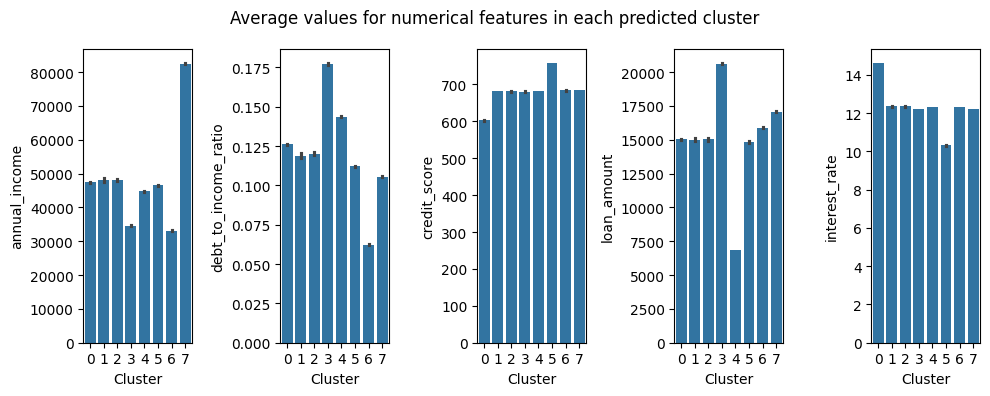

In [28]:
vars_of_int = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

fig, ax = plt.subplots(1,5, figsize=(10,4))

for i, col in enumerate(vars_of_int):
    sns.barplot(df_cls, x='Cluster', y=col, legend=False, orient='v', ax=ax[i])

plt.suptitle('Average values for numerical features in each predicted cluster')
plt.tight_layout()
plt.show()

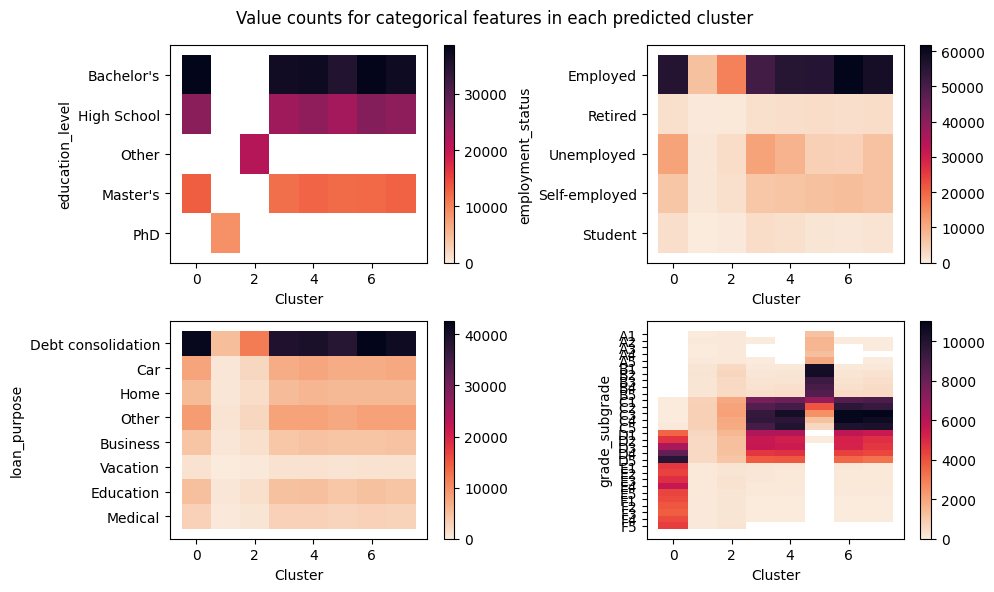

In [29]:
vars_of_int = df_cls.select_dtypes(exclude='number').columns.to_list()#['employment_status', 'grade_subgrade']
vars_of_int.remove('gender')
vars_of_int.remove('marital_status')

fig, ax = plt.subplots(2,2, figsize=(10,6))

for i, col in enumerate(vars_of_int):
    sns.histplot(df_cls.sort_values(by='grade_subgrade'), x='Cluster', y=col, cbar=True, cmap='rocket_r', discrete=True, ax=ax.flat[i])

plt.suptitle('Value counts for categorical features in each predicted cluster')
plt.tight_layout()
plt.show()

## Construct model

The model to be deployed is constructed using pipelines, summarizing the key steps described in the previous section.

In [30]:
num_cols = X_train.select_dtypes(include='number').columns.to_list()
num_cols.remove('id')

cat_cols = X_train.select_dtypes(exclude='number').columns.to_list()
cat_cols.remove('education_level')
cat_cols.remove('grade_subgrade')

ed_order = [["Other", "High School", "Bachelor's", "Master's", "PhD"]]
grade_order = [sorted(X_train.grade_subgrade.unique())]

preprocessor = ColumnTransformer(transformers=[('num', make_pipeline('passthrough'), num_cols), 
                                               ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols), 
                                               ('ed', OrdinalEncoder(categories=ed_order), ['education_level']),
                                               ('grade', OrdinalEncoder(categories=grade_order), ['grade_subgrade'])
                                              ])

union = FeatureUnion([('all', 'passthrough'), ("knn", KMeans(n_clusters=8, random_state=10))])

pipe = Pipeline(steps=[('preprocessor', preprocessor),
                       ('scaler', QuantileTransformer(random_state=0, output_distribution='normal')),
                       ('pca', PCA(n_components=12)),
                       ('union', union),
                       ('model', XGBClassifier(max_depth=10, min_child_weight=50, random_state=0))
                      ])

In [31]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [32]:
pipe.score(X_train, y_train)

0.9040730647418428

## Validate model

Evaluate the model using approapriate metrics on the validation dataset.

In [33]:
y_preds = pipe.predict(X_val)
y_prob = pipe.predict_proba(X_val)

In [34]:
print(f'AUC score = {roc_auc_score(y_val, y_prob.T[1]):.3f}\n\n{classification_report(y_val, y_preds)}')

AUC score = 0.907

              precision    recall  f1-score   support

         0.0       0.88      0.58      0.70     23900
         1.0       0.90      0.98      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.89      0.78      0.82    118799
weighted avg       0.90      0.90      0.89    118799



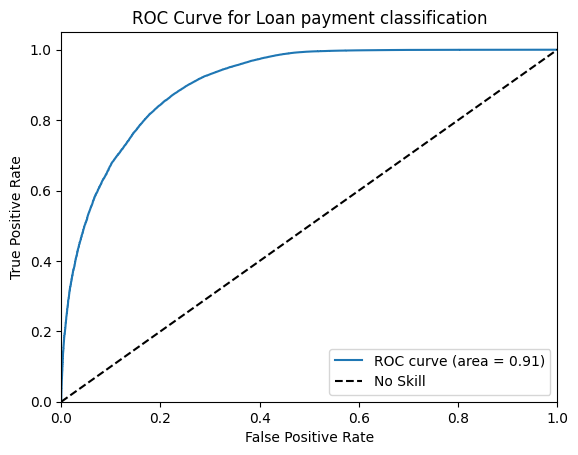

In [35]:
fpr, tpr, thresholds = roc_curve(y_val, y_prob.T[1])
roc_auc = auc(fpr, tpr)

plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan payment classification')
plt.legend()
plt.show()

## Load and predict on test data

In [36]:
test_data = pd.read_csv('k_5_11_test.csv')
test_data.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [37]:
y_preds = pipe.predict(test_data)
y_prob = pipe.predict_proba(test_data)
output = pd.DataFrame(np.round(y_prob.T[1],1), index=test_data.id, columns=['loan_paid_back'])
output.head()

,loan_paid_back
id,
593994,0.9
593995,1.0
593996,0.4
593997,0.9
593998,1.0
